In [1]:
# Phase 2 — Exploratory Data Analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the clean data
df = pd.read_csv('cleaned_weather_data.csv')
df['last_updated'] = pd.to_datetime(df['last_updated'])

print("Data loaded:", df.shape)
plt.style.use('seaborn-v0_8')
print("Ready for EDA! ✅")

Data loaded: (136315, 45)
Ready for EDA! ✅


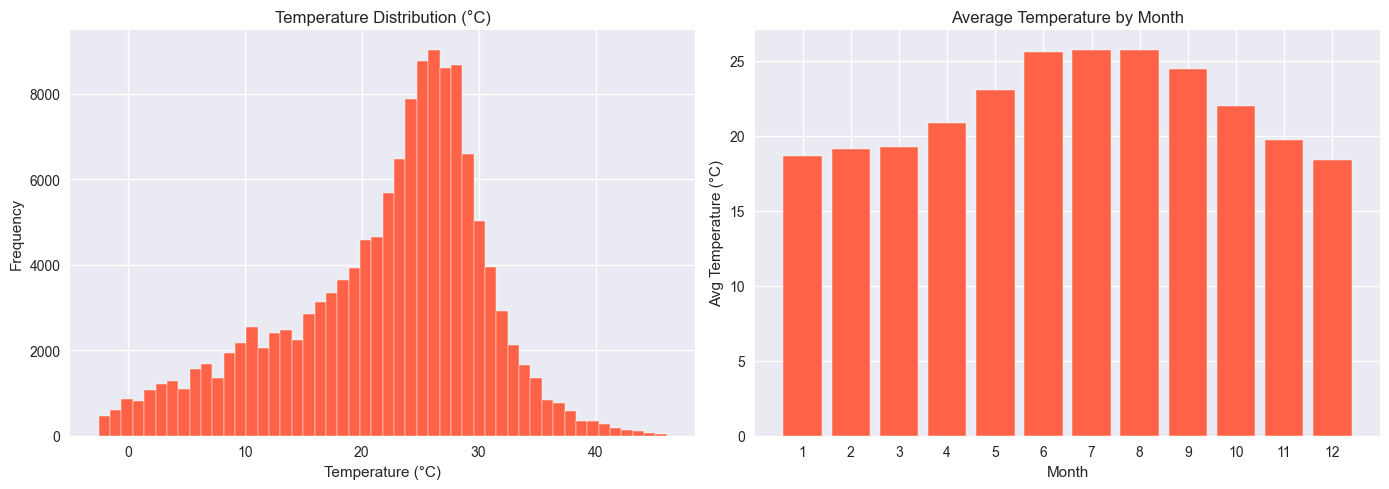

✅ Temperature plot saved!


In [2]:
# Plot 1: Temperature Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['temperature_celsius'], bins=50, color='tomato', edgecolor='white')
axes[0].set_title('Temperature Distribution (°C)')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Frequency')

# Box plot by month
monthly_temp = df.groupby('month')['temperature_celsius'].mean()
axes[1].bar(monthly_temp.index, monthly_temp.values, color='tomato', edgecolor='white')
axes[1].set_title('Average Temperature by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Avg Temperature (°C)')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.savefig('plot_temperature.png', dpi=150)
plt.show()
print("✅ Temperature plot saved!")

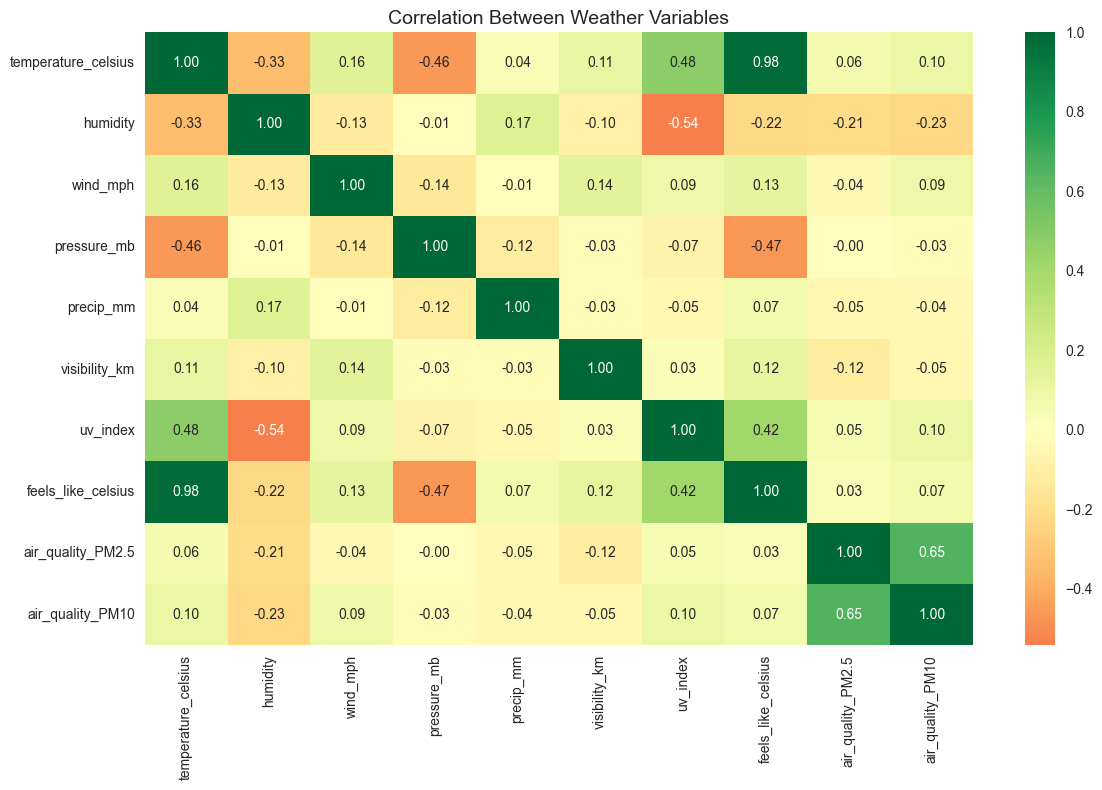

✅ Correlation heatmap saved!


In [3]:
# Plot 3: Correlation Heatmap
fig, ax = plt.subplots(figsize=(12, 8))

cols = ['temperature_celsius', 'humidity', 'wind_mph', 
        'pressure_mb', 'precip_mm', 'visibility_km', 
        'uv_index', 'feels_like_celsius',
        'air_quality_PM2.5', 'air_quality_PM10']

corr_matrix = df[cols].corr()

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn',
            center=0,
            ax=ax)

ax.set_title('Correlation Between Weather Variables', fontsize=14)
plt.tight_layout()
plt.savefig('plot_correlation.png', dpi=150)
plt.show()
print("✅ Correlation heatmap saved!")

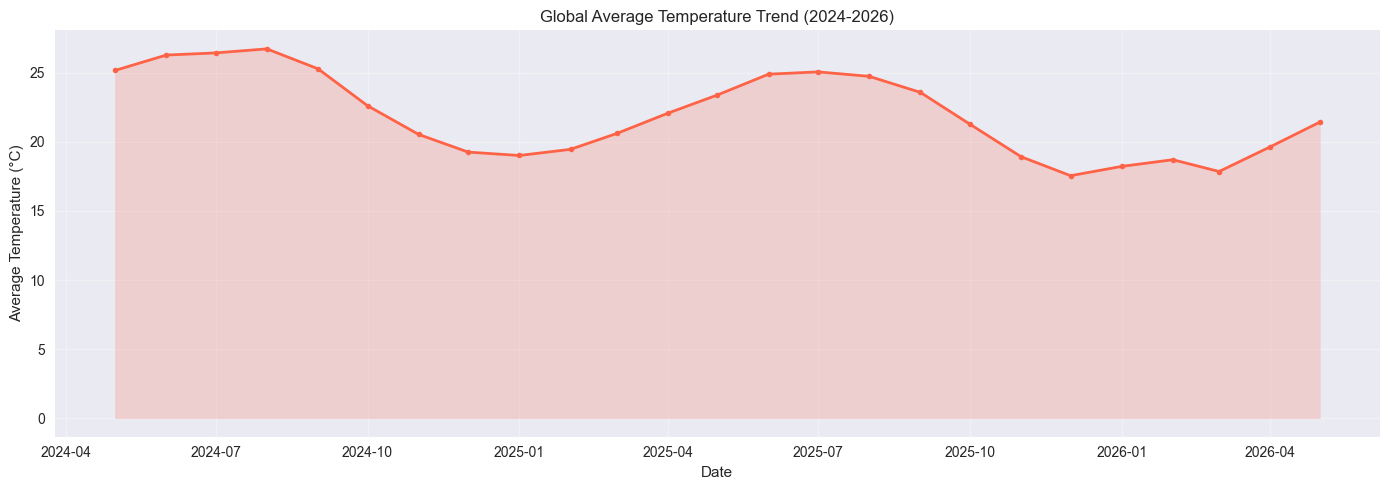

✅ Temperature trend saved!


In [4]:
# Plot 4: Temperature trend over time
monthly = df.groupby(['year', 'month'])['temperature_celsius'].mean().reset_index()
monthly['date'] = pd.to_datetime(monthly[['year', 'month']].assign(day=1))

plt.figure(figsize=(14, 5))
plt.plot(monthly['date'], monthly['temperature_celsius'], 
         color='tomato', linewidth=2, marker='o', markersize=4)
plt.fill_between(monthly['date'], monthly['temperature_celsius'], 
                 alpha=0.2, color='tomato')
plt.title('Global Average Temperature Trend (2024-2026)')
plt.xlabel('Date')
plt.ylabel('Average Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plot_temp_trend.png', dpi=150)
plt.show()
print("✅ Temperature trend saved!")